# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** → dense region  
2. **Border point** → not dense itself, but within `eps` of a core point  
3. **Noise point** → neither core nor border (isolated points)
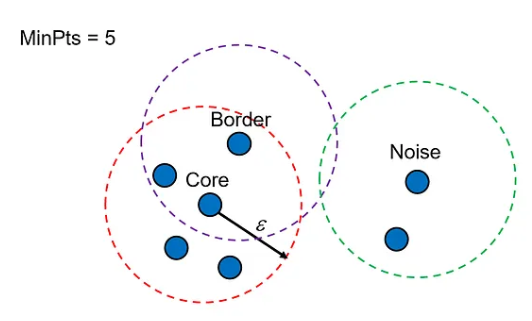

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` → more points are labeled as **noise**  

- Larger `eps` → clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller → clusters form more easily, fewer noise points

- Larger → only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered “neighbors”

**Default:** `euclidean`

**Common options:**  
  - `euclidean` → straight-line distance; most common for numeric features  
  - `manhattan` → sum of absolute differences; robust to outliers  
  - `cosine` → measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

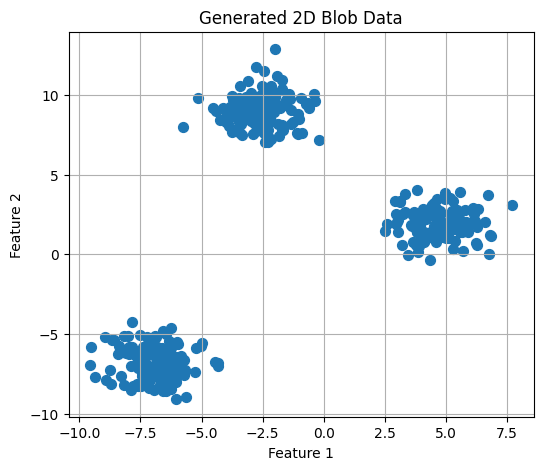

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [2]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

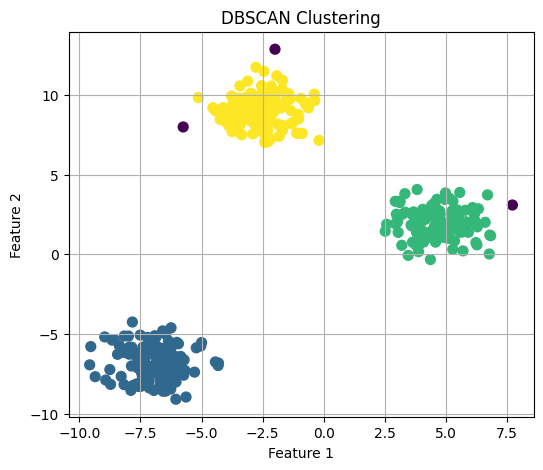

In [3]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [4]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [5]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

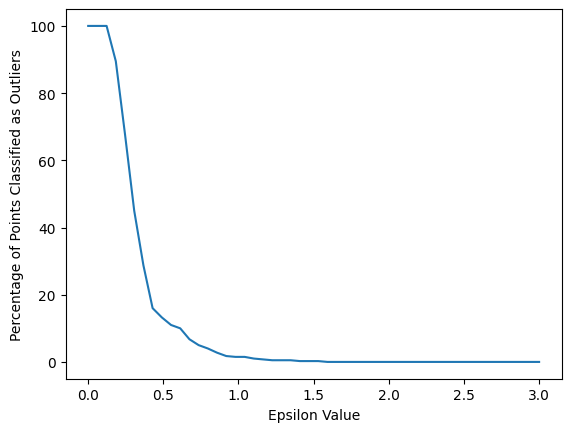

In [6]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

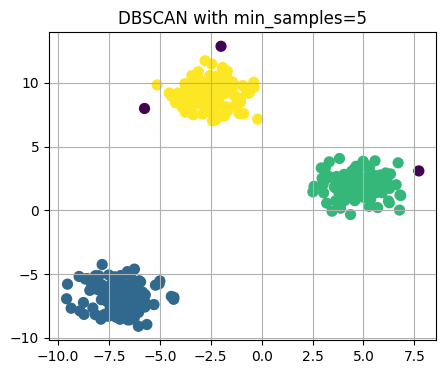

min_samples=5 → Silhouette Score: 0.848


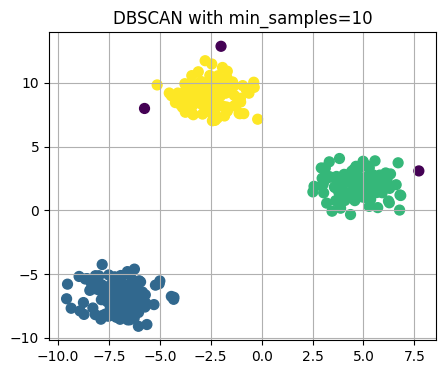

min_samples=10 → Silhouette Score: 0.848


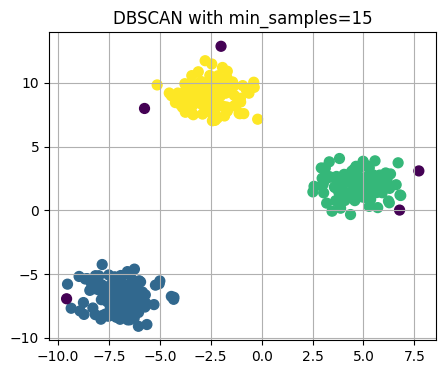

min_samples=15 → Silhouette Score: 0.849


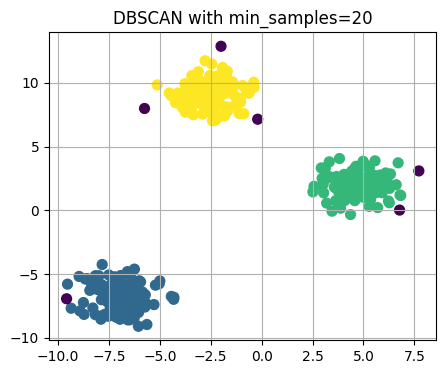

min_samples=20 → Silhouette Score: 0.850


In [7]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} → Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



In [4]:
import pandas as pd

path=r"C:\Users\smart\OneDrive\Documents\Semester 10\Machine Learning\Lab 2\CC GENERAL.csv"
df = pd.read_csv(path, sep=",")

print(df.head())

print(df.shape)
print(df.dtypes)


  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

In [5]:
#Identify Numeric vs Categorical Features
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')
Categorical: Index(['CUST_ID'], dtype='object')


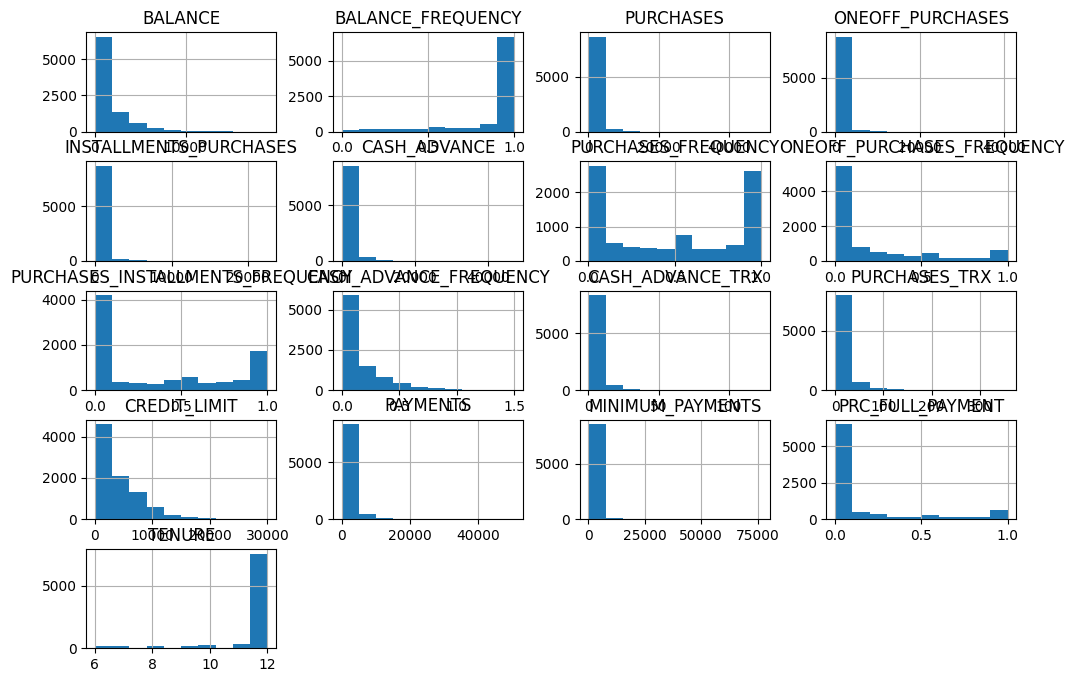

In [ ]:
#Distribution of Numeric Features
df[numeric_cols].describe()
df[numeric_cols].skew()

import matplotlib.pyplot as plt

df[numeric_cols].hist(figsize=(12,8))
plt.show()

#Observations => very skwed distributions to the left

In [7]:
#Counts of Categories
for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 CUST_ID
CUST_ID
C19190    1
C10001    1
C10002    1
C10003    1
C10004    1
         ..
C10011    1
C10010    1
C10009    1
C10008    1
C10007    1
Name: count, Length: 8950, dtype: int64


In [26]:
#Missing data

import numpy as np

print( df.isnull().sum())

#No missing values to be handeled 


CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


                                   BALANCE  BALANCE_FREQUENCY  PURCHASES  \
BALANCE                           1.000000           0.322412   0.181261   
BALANCE_FREQUENCY                 0.322412           1.000000   0.133674   
PURCHASES                         0.181261           0.133674   1.000000   
ONEOFF_PURCHASES                  0.164350           0.104323   0.916845   
INSTALLMENTS_PURCHASES            0.126469           0.124292   0.679896   
CASH_ADVANCE                      0.496692           0.099388  -0.051474   
PURCHASES_FREQUENCY              -0.077944           0.229715   0.393017   
ONEOFF_PURCHASES_FREQUENCY        0.073166           0.202415   0.498430   
PURCHASES_INSTALLMENTS_FREQUENCY -0.063186           0.176079   0.315567   
CASH_ADVANCE_FREQUENCY            0.449218           0.191873  -0.120143   
CASH_ADVANCE_TRX                  0.385152           0.141555  -0.067175   
PURCHASES_TRX                     0.154338           0.189626   0.689561   
CREDIT_LIMIT

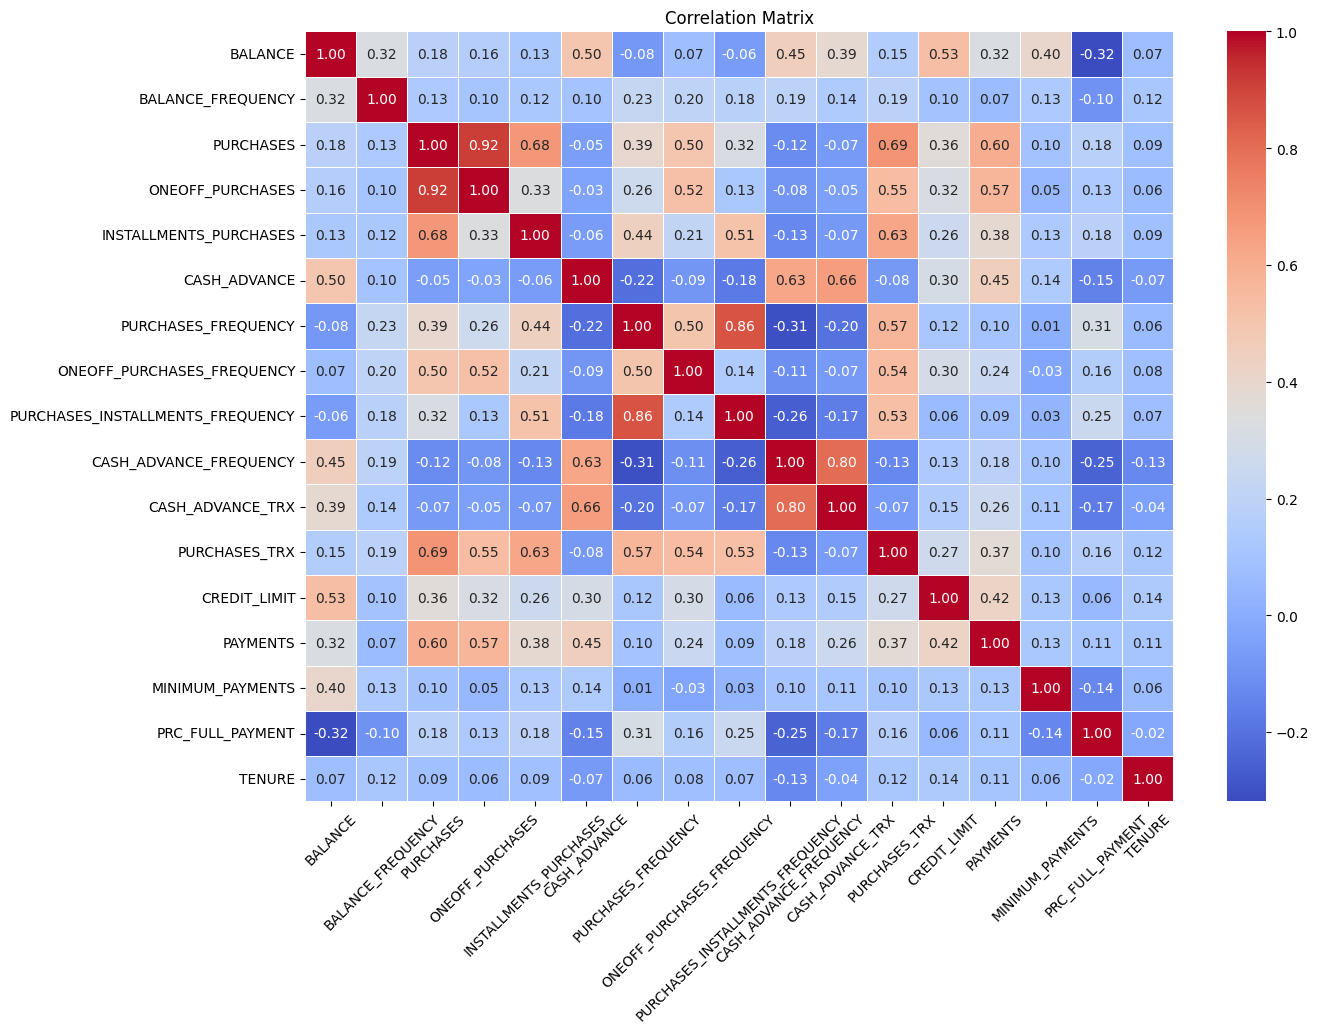

In [16]:
#Correlation Between Numeric Features
corr = df[numeric_cols].corr()
print(corr)

import seaborn as sns
import matplotlib.pyplot as plt
df_numeric = df.drop("CUST_ID", axis=1)

plt.figure(figsize=(14,10))
sns.heatmap(df_numeric.corr(), 
            annot=True, 
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Matrix")
plt.show()

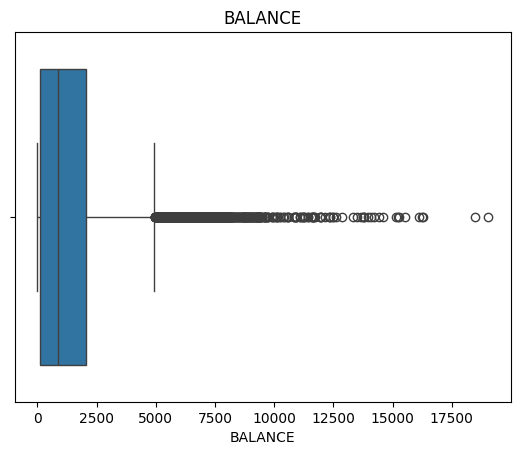

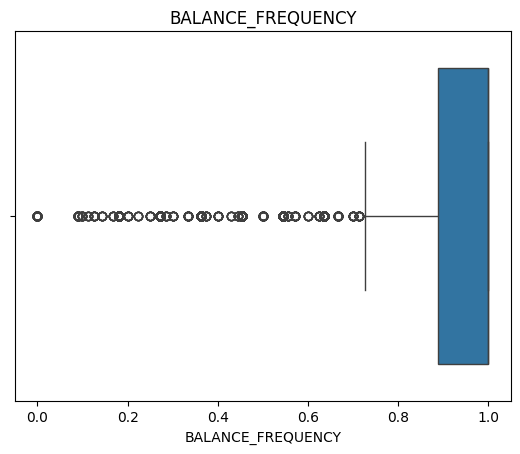

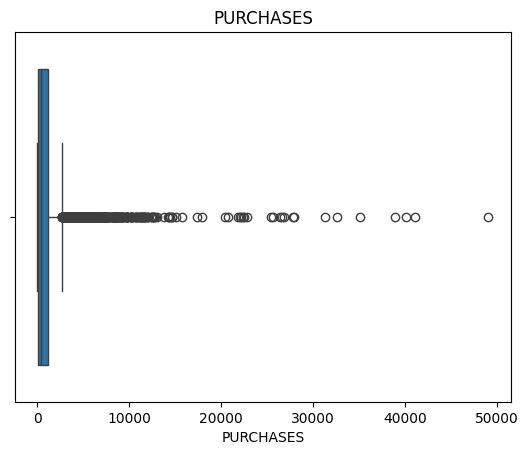

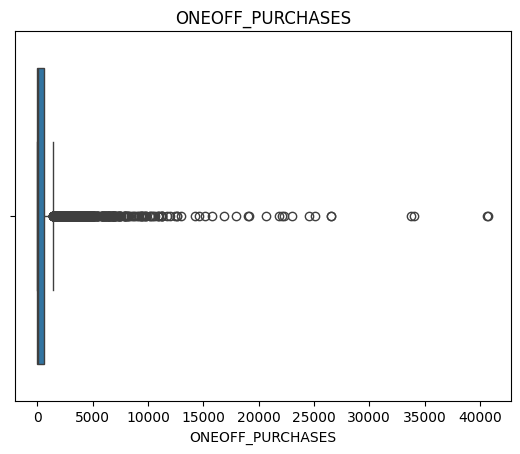

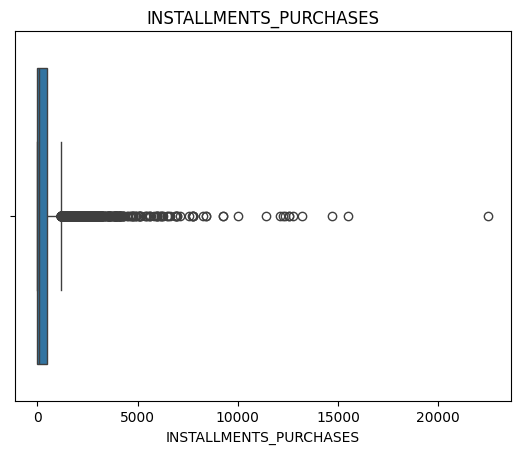

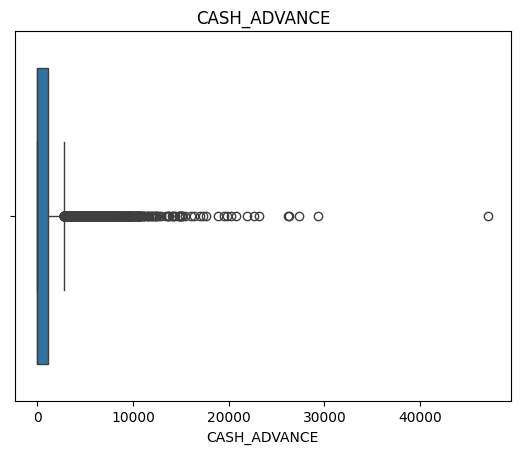

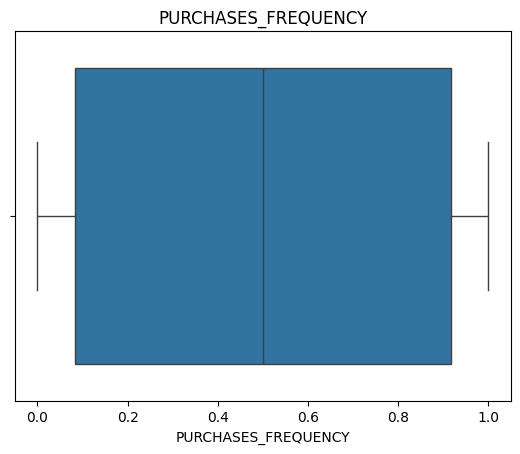

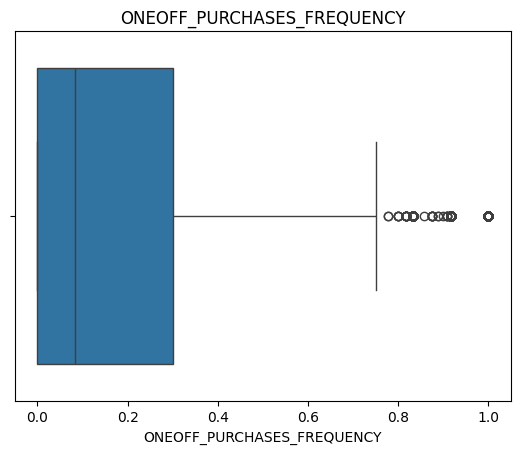

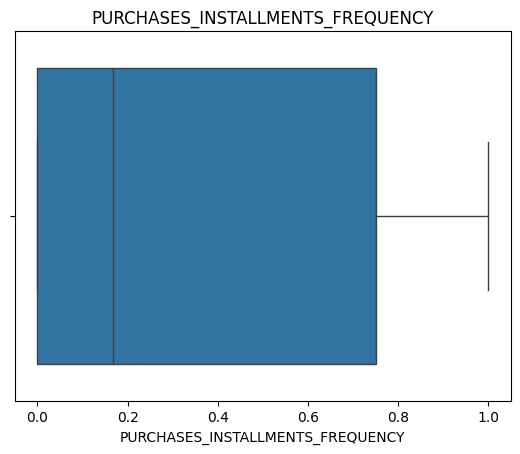

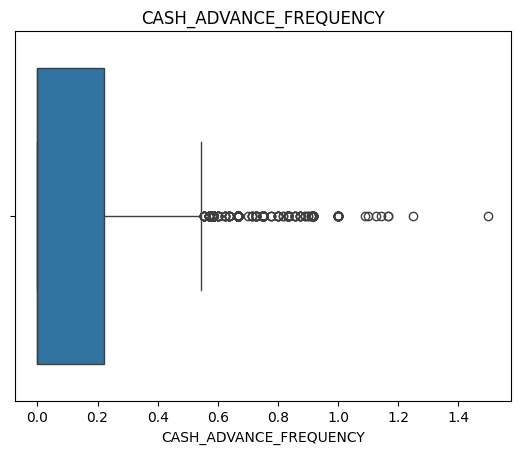

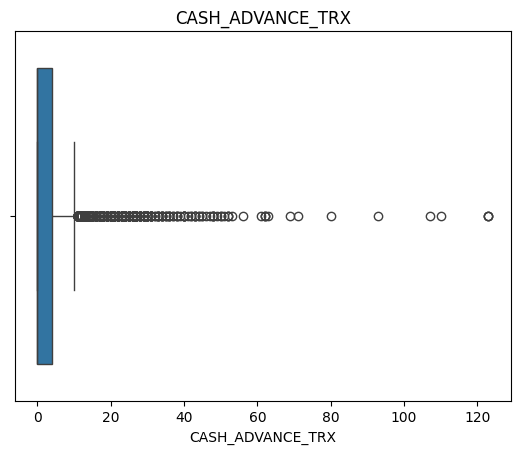

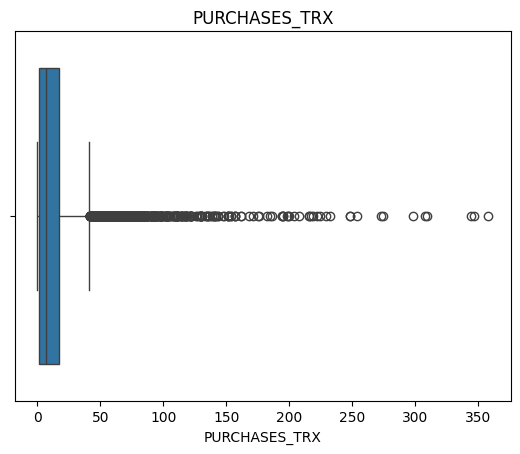

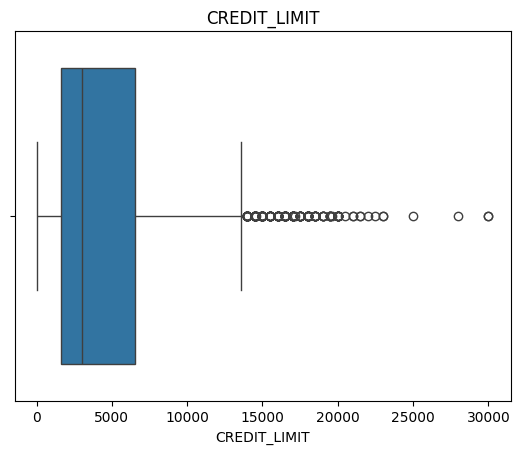

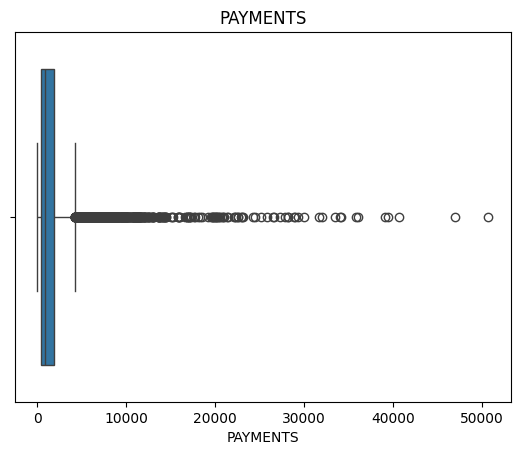

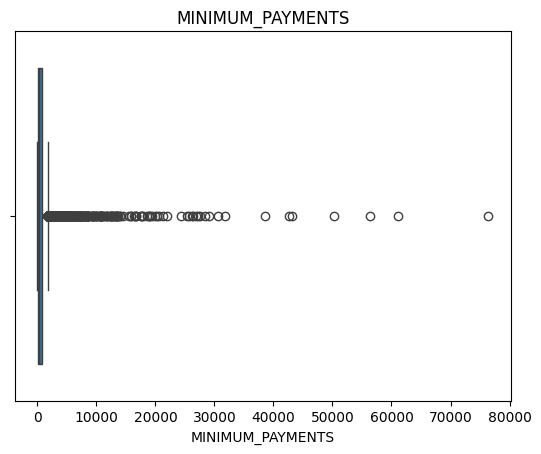

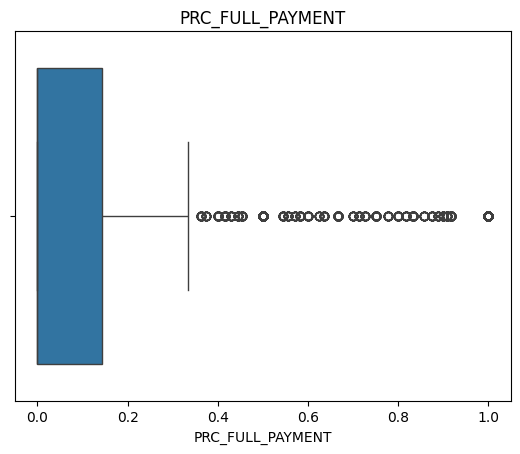

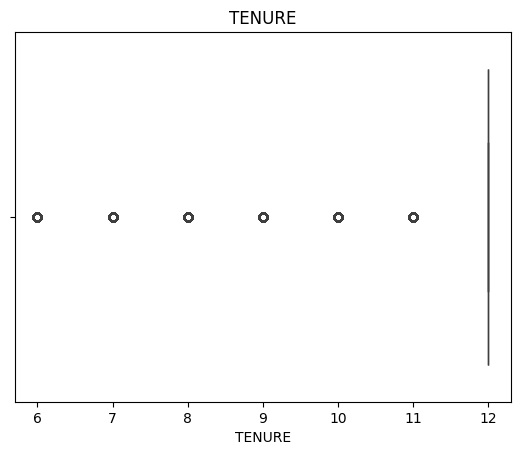

In [18]:
#Outliers
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

#After ploting it is obvious that we need to handel the outliers
# so I choose Log Transform
import numpy as np

skewed_cols = [
    'BALANCE','PURCHASES','ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES','CASH_ADVANCE',
    'PAYMENTS','MINIMUM_PAYMENTS','CREDIT_LIMIT'
]

for col in skewed_cols:
    df[col] = np.log1p(df[col]) 

## 2. Data Preparation

In [22]:
#Dropping
df_model = df.copy()

# drop the ids that has no meaning (C1001...)
df_model=df_model.drop("CUST_ID", axis=1)


In [23]:
#Encoding
#No need for encoding as all features are already numerical!

from sklearn.preprocessing import  StandardScaler

#Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)

In [25]:
#Final check on the dataset after data prepration
print("Missing values:\n", pd.DataFrame(df_scaled).isnull().sum().sum())
print("Shape:", df_scaled.shape)
print("Data type:", type(df_scaled))

Missing values:
 0
Shape: (8950, 17)
Data type: <class 'numpy.ndarray'>


## 3. Apply DBSCAN




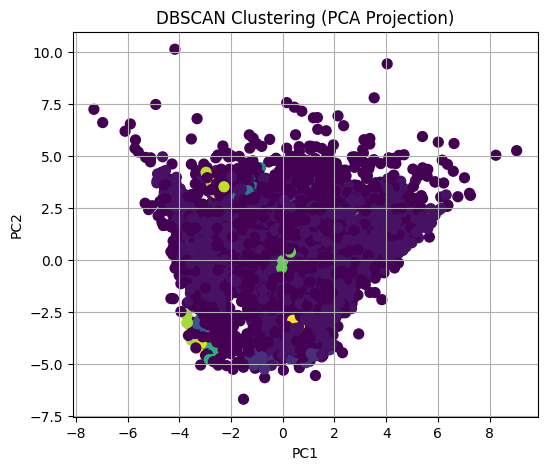

In [34]:

# Create DBSCAN model
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(df_scaled)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], 
            X_pca[:, 1], 
            c=labels, 
            cmap='viridis', 
            s=50)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering (PCA Projection)")
plt.grid(True)
plt.show()



## 4. Evaluate the Clustering

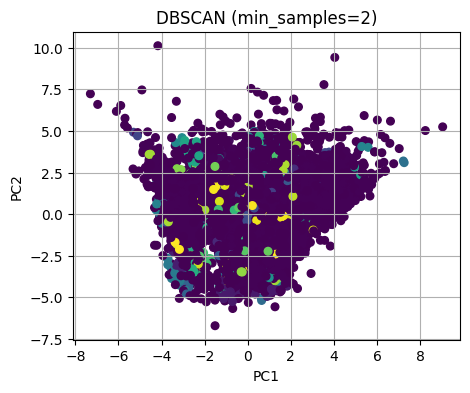

min_samples=2 → Clusters: 192, Noise: 1768, Silhouette Score: -0.452


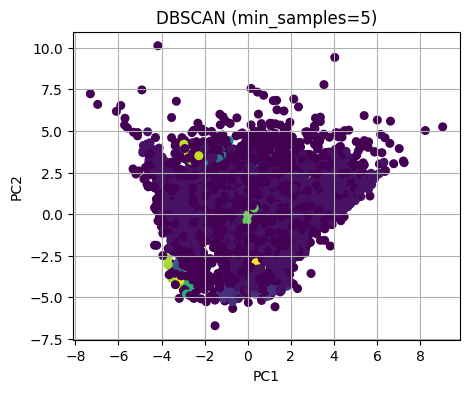

min_samples=5 → Clusters: 22, Noise: 2401, Silhouette Score: -0.240


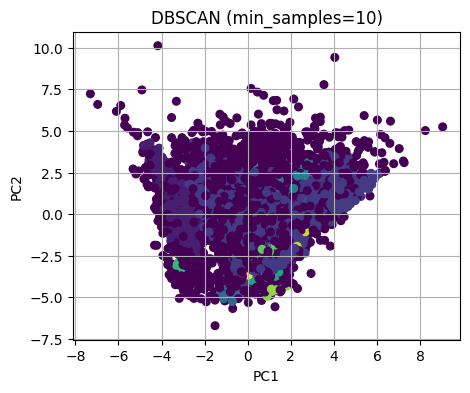

min_samples=10 → Clusters: 12, Noise: 3193, Silhouette Score: -0.009


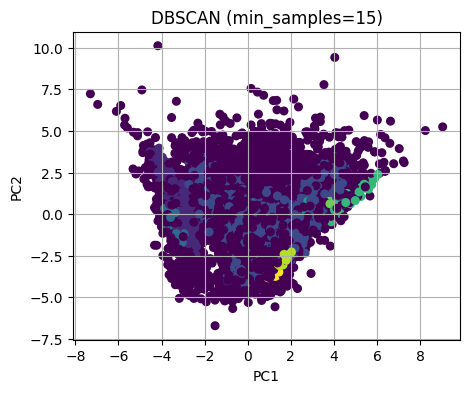

min_samples=15 → Clusters: 9, Noise: 3979, Silhouette Score: 0.017


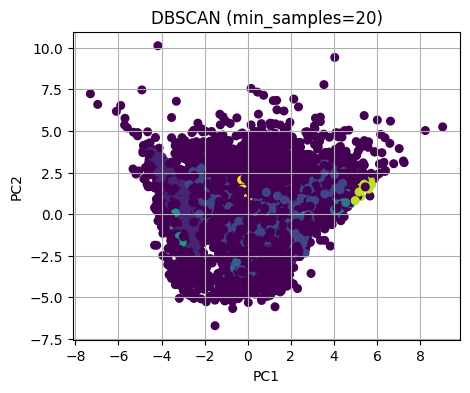

min_samples=20 → Clusters: 10, Noise: 4474, Silhouette Score: 0.072


In [ ]:
#Evaluating Using the Silhouette score to measure how good DBSCAN performed in different values including the sample above
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Reduce dimensionality for visualization ONLY
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

min_samples_values = [2, 5, 10, 15, 20]

for min_samples in min_samples_values:
    
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(df_scaled)
    
    # ---- Visualization (PCA projection) ----
    plt.figure(figsize=(5,4))
    plt.scatter(X_pca[:,0], X_pca[:,1], 
                c=labels, cmap='viridis', s=30)
    plt.title(f"DBSCAN (min_samples={min_samples})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()
    
    # ---- Evaluation ----
    mask = labels != -1   # remove noise
    
    unique_clusters = set(labels[mask])
    
    if len(unique_clusters) > 1:
        score = silhouette_score(df_scaled[mask], labels[mask])
        print(f"min_samples={min_samples} → "
              f"Clusters: {len(unique_clusters)}, "
              f"Noise: {sum(labels==-1)}, "
              f"Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → "
              "Too few clusters to compute silhouette score")
        
# Very bad silhouette score for all(very weak clustering )        